# EM Tutorial: Two-State Sensorimotor Adaptation

This notebook demonstrates how to use the `albert_em` Python package to: 
1. Define an experimental paradigm containing perturbation and error-clamp trials.
2. Simulate noisy behavior from a known two-state model.
3. Fit the model parameters with the Expectation-Maximization (EM) algorithm.
4. Visualize behavioral data, hidden states, and convergence (log-likelihood).

The implementation uses Numba for performance and falls back to pure Python if disabled.

In [2]:
# Imports and environment setup
import os, sys, time, math
from pathlib import Path
# Ensure src/ is on the path if working from a clone without install
repo_root = Path('..').resolve()
src_path = repo_root / 'src'
if src_path.exists() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import numpy as np
import matplotlib.pyplot as plt
from albert_em import (
    generalized_expectation_maximization,
    two_state_simulation_with_noise,
    two_state_simulation_without_noise
)

# Detect whether numba optimization is active (best-effort)
try:
    import numba
    USING_NUMBA = (os.getenv('ALBERT_EM_DISABLE_NUMBA', '0') != '1')
except ImportError:
    USING_NUMBA = False

print(f'Numba acceleration active: {USING_NUMBA}')

Numba acceleration active: True


In [3]:
# Part 1: Define paradigm (perturbations + error-clamp trials)
r = np.concatenate([
    np.zeros(20),           # baseline
    30 * np.ones(50),       # adaptation perturbation (30)
    np.full(20, np.nan),    # error-clamp trials
    np.zeros(30)            # washout
])
EC = np.concatenate([
    np.zeros(70),           # normal trials
    np.ones(20),            # error-clamp
    np.zeros(30)            # normal
])
EC_value = np.concatenate([
    np.full(70, np.nan),    # not clamped
    np.zeros(20),           # clamped error value = 0
    np.full(30, np.nan)     # not clamped
])
c = np.array([1.0, 1.0])  # equal weighting of states
N = len(r)
print(f'Total trials: {N}')

Total trials: 120


In [4]:
# Part 2: Simulate noisy behavior from known parameters
true_params = np.array([
    0.985,  # aS slow retention
    0.556,  # aF fast retention
    0.097,  # bS slow error sensitivity
    0.213,  # bF fast error sensitivity
    0.0,    # xS1 initial slow state
    0.0,    # xF1 initial fast state
    1.694,  # sigmax2 state update variance
    1.037,  # sigmau2 motor variance
    0.0     # sigma12 initial state variance
])
np.random.seed(5)
y_obs, xS_true, xF_true = two_state_simulation_with_noise(true_params, r, EC, EC_value, c)
print('Simulated motor output (first 10):', y_obs[:10])

Simulated motor output (first 10): [ 2.47533201  0.65869214 -2.74010993 -3.74588137 -3.01611336  1.81357329
 -3.84977527 -5.09273189 -1.03777446 -2.37086875]


In [5]:
# Part 3: Configure EM algorithm
search_space = np.array([
    [0, 1.1], [0, 1.1], [0, 1], [0, 1],
    [-30, 30], [-30, 30],
    [1e-7, 10], [1e-7, 10], [1e-7, 10]
])
constraints = np.array([0.001, 0.001])  # enforce aS>aF+deltaA and bF>bS+deltaB
initial_guess = np.array([0.95, 0.7, 0.05, 0.30, 0, 0, 2, 2, 5])
num_iterations = 60  # fewer iterations for notebook demo
start = time.time()
fitted_params, likelihoods = generalized_expectation_maximization(
    initial_guess, y_obs, r, EC, EC_value, c, search_space, constraints, num_iterations
)
elapsed = time.time() - start
print(f'EM finished in {elapsed:.2f}s')
print('Initial likelihood:', likelihoods[0])
print('Final likelihood:', likelihoods[-1])
improvement = likelihoods[-1] - likelihoods[0]
print(f'Improvement: {improvement:.2f}')
# Basic monotonicity check (allow small numerical noise)
non_decreasing = np.all(np.diff(likelihoods) > -1e-6)
print('Likelihood non-decreasing:', non_decreasing)

EM finished in 16.31s
Initial likelihood: -273.24825052817374
Final likelihood: -268.20372707979806
Improvement: 5.04
Likelihood non-decreasing: True


In [7]:
# Part 4: Inspect fitted parameters vs truth
names = ['aS','aF','bS','bF','xS1','xF1','sigmax2','sigmau2','sigma12']
print("\nParameter Comparison:")
print("{:<8} {:>10} {:>10} {:>10}".format("Param", "True", "Init", "Fitted"))
for i, n in enumerate(names):
    print(f"{n:<8} {true_params[i]:>10.4f} {initial_guess[i]:>10.4f} {fitted_params[i]:>10.4f}")


Parameter Comparison:
Param          True       Init     Fitted
aS           0.9850     0.9500     0.9840
aF           0.5560     0.7000     0.7292
bS           0.0970     0.0500     0.1103
bF           0.2130     0.3000     0.1714
xS1          0.0000     0.0000    -0.8046
xF1          0.0000     0.0000     3.1128
sigmax2      1.6940     2.0000     1.7467
sigmau2      1.0370     2.0000     0.9140
sigma12      0.0000     5.0000     0.0162


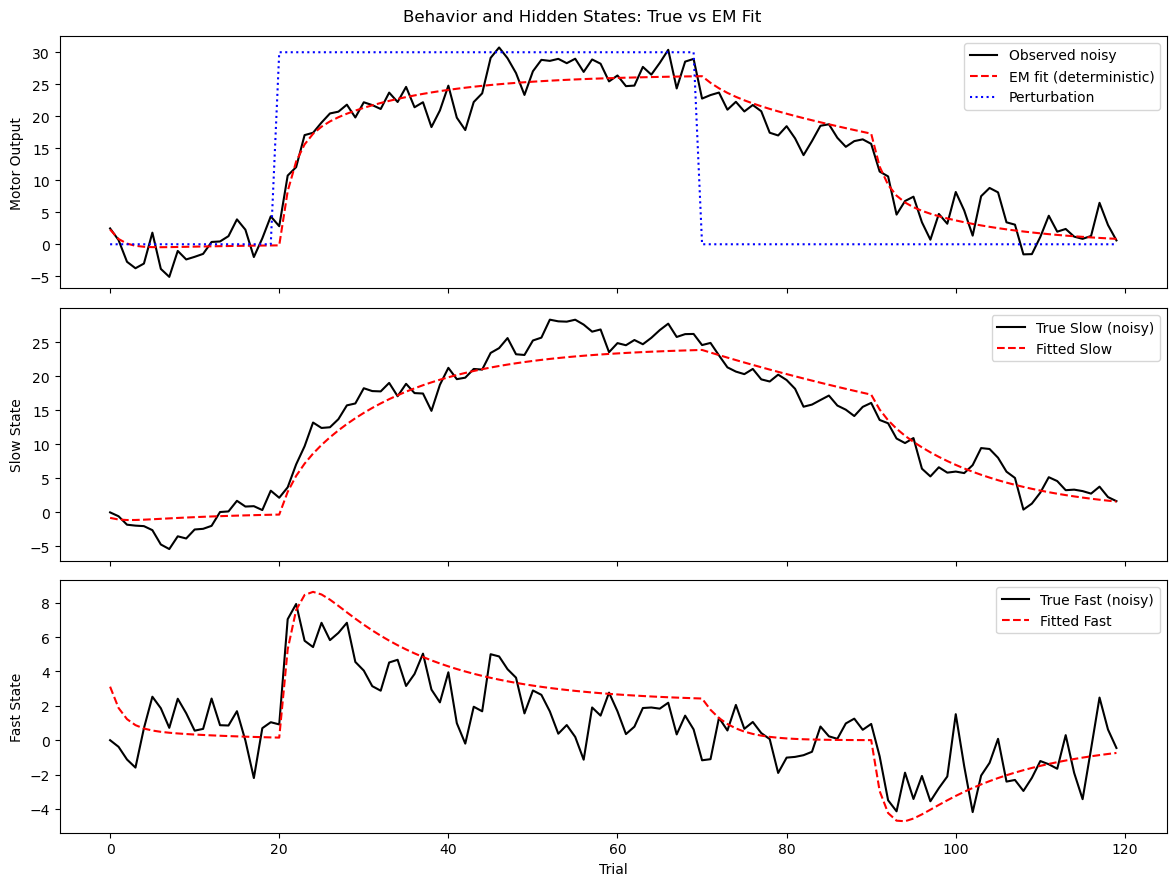

In [8]:
# Part 5: Simulate deterministic (noise-free) trajectories with fitted params
y_fit, xS_fit, xF_fit = two_state_simulation_without_noise(fitted_params, r, EC, EC_value, c)
# Plot behavior and state trajectories
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].plot(y_obs, 'k', label='Observed noisy')
axes[0].plot(y_fit, '--r', label='EM fit (deterministic)')
axes[0].plot(np.nan_to_num(r, nan=0.0), ':b', label='Perturbation')
axes[0].set_ylabel('Motor Output')
axes[0].legend(loc='upper right')
axes[1].plot(xS_true, 'k', label='True Slow (noisy)')
axes[1].plot(xS_fit, '--r', label='Fitted Slow')
axes[1].set_ylabel('Slow State')
axes[1].legend(loc='upper right')
axes[2].plot(xF_true, 'k', label='True Fast (noisy)')
axes[2].plot(xF_fit, '--r', label='Fitted Fast')
axes[2].set_ylabel('Fast State')
axes[2].set_xlabel('Trial')
axes[2].legend(loc='upper right')
fig.suptitle('Behavior and Hidden States: True vs EM Fit')
plt.tight_layout()
plt.show()

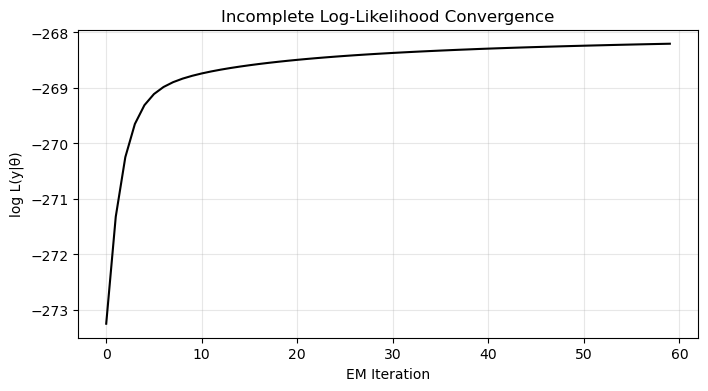

In [9]:
# Part 6: Plot log-likelihood convergence
plt.figure(figsize=(8,4))
plt.plot(likelihoods, 'k')
plt.xlabel('EM Iteration')
plt.ylabel('log L(y|θ)')
plt.title('Incomplete Log-Likelihood Convergence')
plt.grid(alpha=0.3)
plt.show()

## Next Steps
- Adjust `num_iterations` for higher accuracy.
- Provide real experimental data in place of simulated `y_obs`.
- Enable/disable Numba via environment variable: `ALBERT_EM_DISABLE_NUMBA=1`.
- Add batch fitting for multiple subjects.

This concludes the tutorial notebook.

# One-State Model Example

The package also supports a simpler **one-state model** where learning is described by a single hidden state rather than slow/fast processes.

**Model equation:** `x[n] = A*x[n-1] + B*e[n]`  
**Observation:** `y[n] = x[n] + observation noise`

This model is useful for:
- Simpler adaptation paradigms
- Faster computation
- Baseline comparisons with two-state models

In [ ]:
# Import one-state functions
from albert_em import (
    fit_one_state,
    pack_one_state_params,
    one_state_simulation_with_noise,
    one_state_simulation_without_noise
)

# Part 1: Simulate data from a known one-state model
true_params_1s = pack_one_state_params(
    A=0.90,     # retention factor
    B=0.20,     # learning rate
    Q=0.5,      # process noise variance
    R=1.5,      # observation noise variance
    x0=0.0,     # initial state mean
    P0=1.0      # initial state variance
)

# Use same paradigm as two-state example
np.random.seed(42)
y_1s_obs, x_1s_true = one_state_simulation_with_noise(
    true_params_1s, r, EC, EC_value
)
print('One-state simulation complete')
print('Observed motor output (first 10):', y_1s_obs[:10])

In [ ]:
# Part 2: Fit the one-state model with EM
bounds_1s = np.array([
    [0.0, 1.0],      # A bounds
    [0.0, 1.0],      # B bounds
    [1e-6, 10.0],    # Q bounds
    [1e-6, 10.0],    # R bounds
    [-30.0, 30.0],   # x0 bounds
    [1e-6, 10.0]     # P0 bounds
])

initial_guess_1s = pack_one_state_params(
    A=0.85, B=0.15, Q=1.0, R=2.0, x0=0.0, P0=2.0
)

start_1s = time.time()
fitted_params_1s, likelihoods_1s = fit_one_state(
    parameters=initial_guess_1s,
    y=y_1s_obs,
    r=r,
    EC=EC,
    EC_value=EC_value,
    search_space=bounds_1s,
    num_iterations=40
)
elapsed_1s = time.time() - start_1s

print(f'One-state EM finished in {elapsed_1s:.2f}s')
print(f'Initial likelihood: {likelihoods_1s[0]:.2f}')
print(f'Final likelihood: {likelihoods_1s[-1]:.2f}')
print(f'Improvement: {likelihoods_1s[-1] - likelihoods_1s[0]:.2f}')

In [ ]:
# Part 3: Compare fitted vs true parameters
param_names_1s = ['A', 'B', 'Q', 'R', 'x0', 'P0']
print("\nOne-State Parameter Comparison:")
print("{:<6} {:>10} {:>10} {:>10}".format("Param", "True", "Init", "Fitted"))
for i, name in enumerate(param_names_1s):
    print(f"{name:<6} {true_params_1s[i]:>10.4f} "
          f"{initial_guess_1s[i]:>10.4f} {fitted_params_1s[i]:>10.4f}")

In [ ]:
# Part 4: Visualize one-state results
y_1s_fit, x_1s_fit = one_state_simulation_without_noise(
    fitted_params_1s, r, EC, EC_value
)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Motor output
axes[0].plot(y_1s_obs, 'k', label='Observed (noisy)')
axes[0].plot(y_1s_fit, '--r', linewidth=2, label='EM fit (deterministic)')
axes[0].plot(np.nan_to_num(r, nan=0.0), ':b', alpha=0.5, label='Perturbation')
axes[0].set_ylabel('Motor Output')
axes[0].set_title('One-State Model: Behavior and Hidden State')
axes[0].legend(loc='upper right')
axes[0].grid(alpha=0.3)

# Hidden state
axes[1].plot(x_1s_true, 'k', label='True state (noisy)')
axes[1].plot(x_1s_fit, '--r', linewidth=2, label='Fitted state')
axes[1].set_ylabel('Hidden State')
axes[1].set_xlabel('Trial')
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Part 5: Plot one-state likelihood convergence
plt.figure(figsize=(8, 4))
plt.plot(likelihoods_1s, 'k', linewidth=2)
plt.xlabel('EM Iteration')
plt.ylabel('log L(y|θ)')
plt.title('One-State Model: Incomplete Log-Likelihood Convergence')
plt.grid(alpha=0.3)
plt.show()